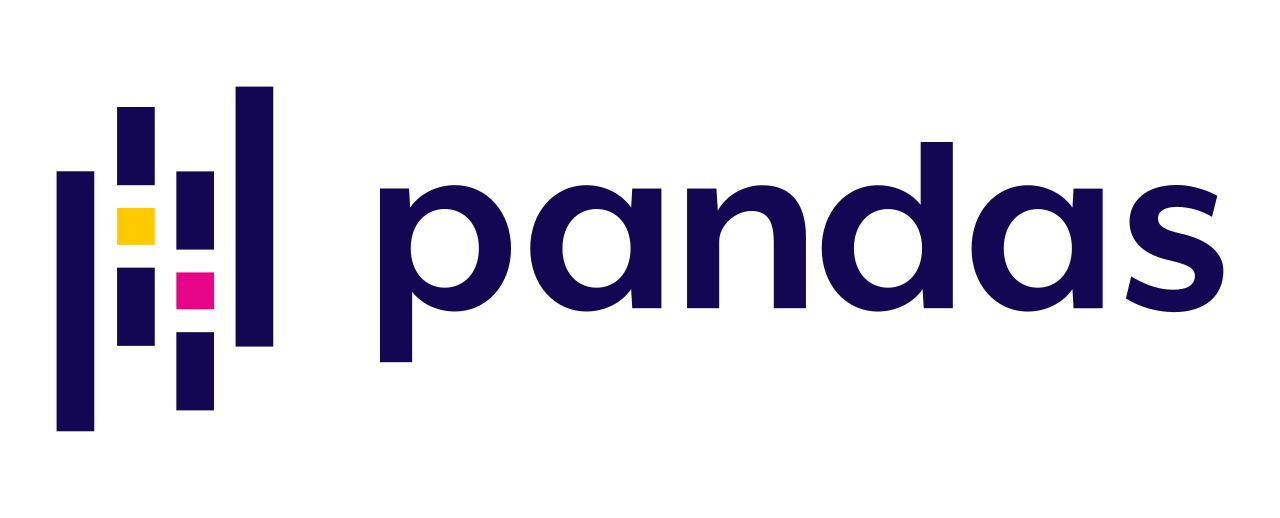

# **Introduction to Pandas**

## **What is Pandas?**
**Pandas** is a powerful and flexible **open-source Python library** used for **data manipulation and analysis**. It provides easy-to-use data structures and tools that make working with structured data fast, intuitive, and expressive.

At its core, Pandas helps you **load, clean, transform, analyze, and visualize data** with just a few lines of code.



## **What Is Pandas Based On?**
Pandas is built on top of several key technologies:

- **NumPy**  
  Pandas uses NumPy arrays internally for fast numerical computation and efficient memory usage.

- **Python**  
  Pandas integrates seamlessly with Python’s syntax and ecosystem.

- **C / Cython (under the hood)**  
  Performance-critical parts are implemented in low-level code for speed.

Because of this foundation, Pandas combines:
- The **performance** of NumPy
- The **flexibility** of Python
- The **readability** of high-level data abstractions



## **Why Use Pandas?**
Pandas is widely used because it simplifies almost every step of data analysis:

### ✅ Easy Data Loading
Read data from multiple sources:
- CSV, Excel, JSON
- SQL databases
- APIs and more

### ✅ Data Cleaning & Preprocessing
- Handle missing values
- Remove duplicates
- Convert data types
- Rename columns
- Filter and sort data

### ✅ Powerful Data Analysis
- Statistical summaries
- Grouping and aggregation
- Time-series analysis
- Window operations

### ✅ Intuitive Syntax
Operations closely match how we think about data:
- Select rows and columns by labels
- Apply functions directly to data
- Chain operations for clean workflows

### ✅ Integration with the Data Science Stack
Pandas works seamlessly with:
- **Matplotlib / Seaborn** (visualization)
- **NumPy** (numerical computing)
- **Scikit-learn** (machine learning)
- **Jupyter / Colab** (interactive analysis)


## **When Should You Use Pandas?**
Use Pandas when you are working with:
- Tabular or structured data
- Datasets that fit in memory
- Exploratory data analysis (EDA)
- Data preprocessing for machine learning
- Academic, scientific, or business data workflows




[Pandas documentation](https://pandas.pydata.org/docs/)


<br><br>

## **Core Data Structures**
Pandas introduces two main data structures:

- **Series**  
  A one-dimensional labeled array (similar to a column in a table)

  Formal definition: One-dimentional ndarray with axis labels

- **DataFrame**  
  A two-dimensional labeled table with rows and columns (similar to an Excel sheet or SQL table)

These labels make data easier to access, filter, and analyze.



<br>

# **Series**

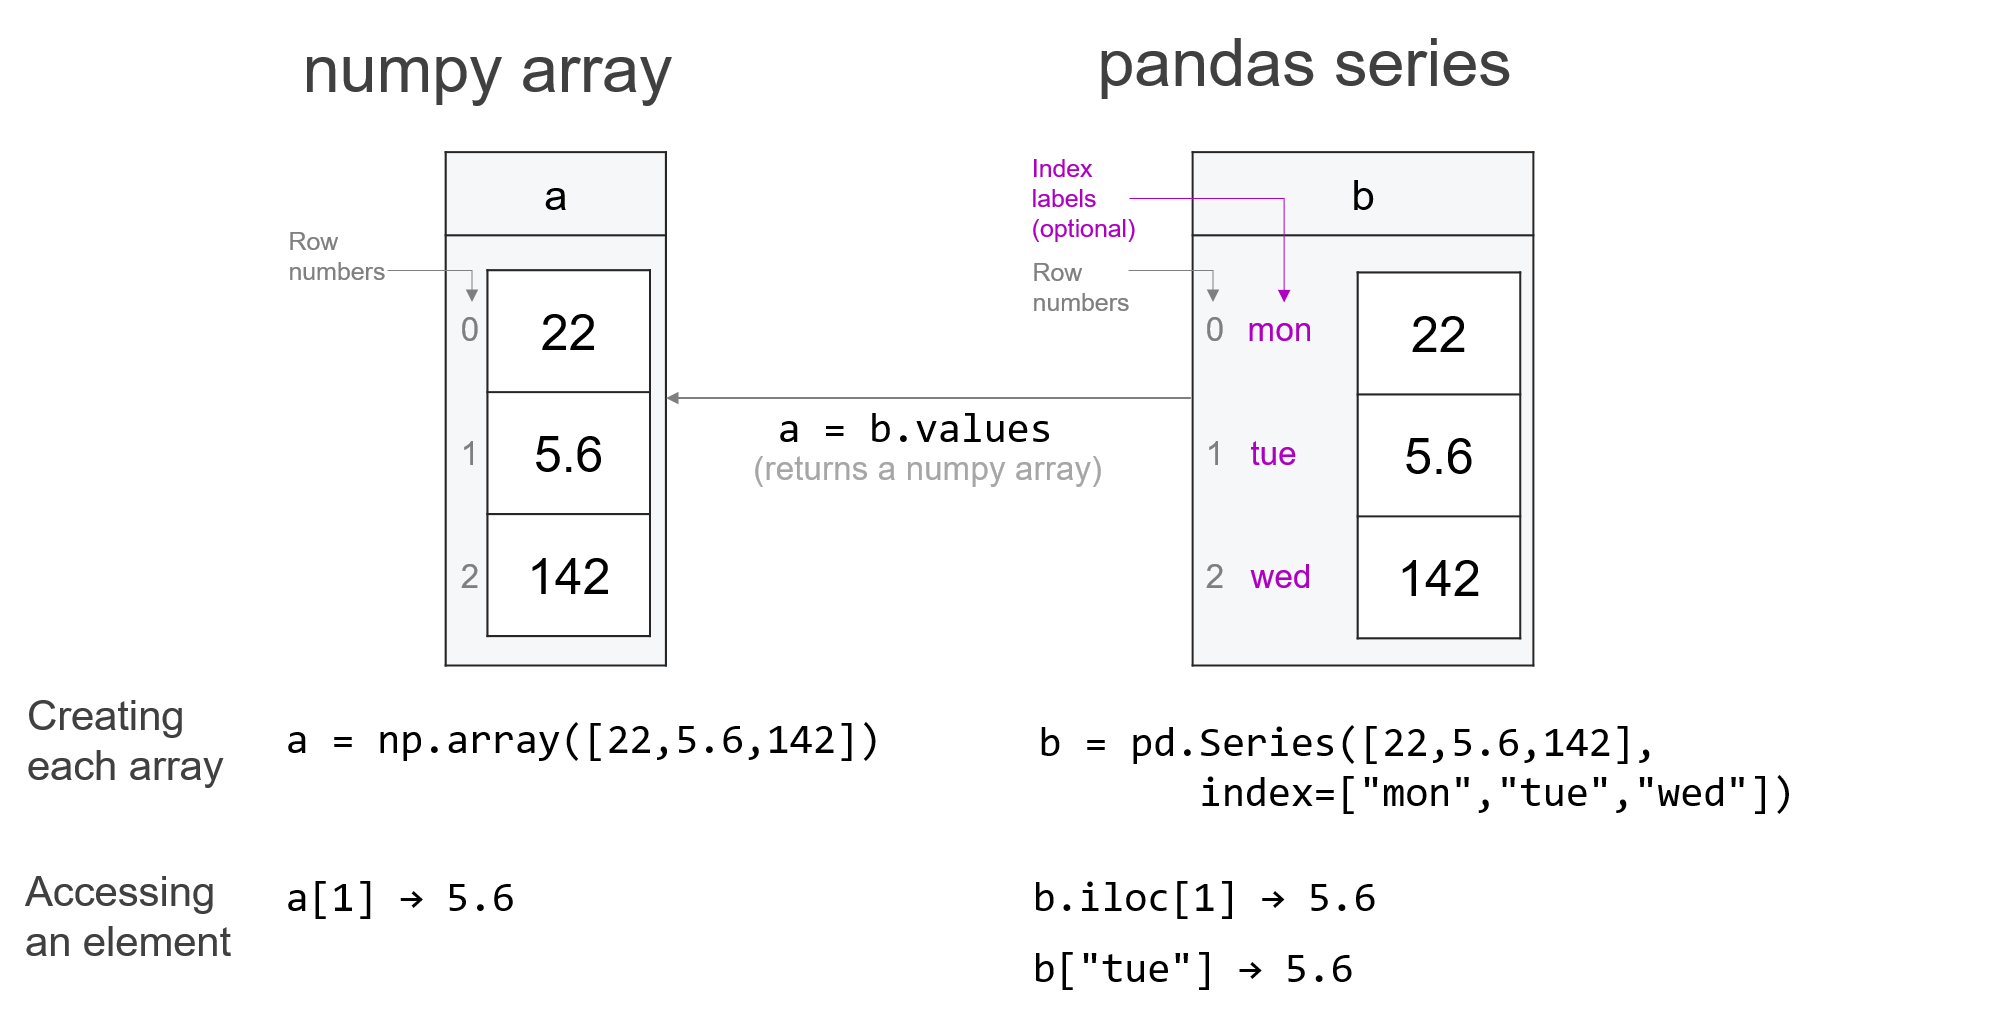

## **Creating a Series from Python Objects**

- ### **Using python lists representing data and index**

    We can create a Series from Python lists (also from NumPy arrays)

In [1]:
import numpy as np
import pandas as pd

In [2]:
mydata = [1776,1867,1821]
myser = pd.Series(data=mydata)
myser

,0
0,1776
1,1867
2,1821


In [3]:
print(myser[0])

1776


In [4]:
myindex = ['USA','Canada','Mexico']
myser = pd.Series(data=mydata,index=myindex)
myser

,0
USA,1776
Canada,1867
Mexico,1821


In [5]:
print(myser['USA'])

1776


Notice that the Series object now work with both the numeric index, and the labeled index.

In [6]:
myser['USA'] == myser[0]

/tmp/ipykernel_1399/929492129.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  myser['USA'] == myser[0]


np.True_

- ### **Using python dictionary**

In [11]:
ages = {'Sam':5,'Frank':10,'Joe':8}
agesP = pd.Series(ages)

In [13]:
agesP[0]

/tmp/ipykernel_1399/1352617006.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  agesP[0]


np.int64(5)

## **Key Ideas of a Series**

### **Named Index**

In [14]:
# Imaginary Sales Data for 1st and 2nd Quarters for Global Company
q1 = {'Japan': 80, 'China': 450, 'India': 200, 'USA': 250}
q2 = {'Brazil': 100, 'India': 210,'USA': 260,'China': 500}

# Convert into Pandas Series
sales_Q1 = pd.Series(q1)
sales_Q2 = pd.Series(q2)

print(sales_Q1)

Japan     80
China    450
India    200
USA      250
dtype: int64


In [15]:
print(sales_Q2)

Brazil    100
India     210
USA       260
China     500
dtype: int64


In [ ]:
# Call values based on Named Index
print(sales_Q1['Japan'])

# Integer Based Location information also retained!
print(sales_Q1[0])

80
80


/tmp/ipython-input-317780694.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(sales_Q1[0])


### **Be careful with potential errors!**

In [ ]:
# Wrong Name
sales_Q1['France']

KeyError: 'France'

In [ ]:
# Accidental Extra Space
sales_Q1['USA ']

KeyError: 'USA '

In [ ]:
# Capitalization Mistake
sales_Q1['usa']

KeyError: 'usa'

<br>

## **Operations**

In [ ]:
# Grab just the index keys
sales_Q1.keys()

Index(['Japan', 'China', 'India', 'USA'], dtype='object')

Assume we want to multiply the sales, recall from python list

In [ ]:
[1,2] * 2

[1, 2, 1, 2]

however on ndarray this operation gets broadcasted

In [ ]:
np.array([1,2]) * 2

array([2, 4])

In [ ]:
sales_Q1 * 2

,0
Japan,160
China,900
India,400
USA,500


In [ ]:
sales_Q1 /100

,0
Japan,0.8
China,4.5
India,2.0
USA,2.5


### **Operations Between Series**

What if we want to calculate total sales for the first half of the year? (summation of q1 & q2)

Because of the labeled index, when we perform operations between two series,it takes the labeled index into account!

Pandas is smart enough and **match things up based off their labeled index.**

However, it's technically not smart enough to know what it should do in the case of the labeled indices **not being present in both series!**

In [16]:
# Notice how Pandas informs you of mismatch with NaN
sales_Q1 + sales_Q2

,0
Brazil,NaN
China,950.0
India,410.0
Japan,NaN
USA,510.0


In [ ]:
# You can fill these with any value you want
sales_Q1.add(sales_Q2, fill_value=0)

,0
Brazil,100.0
China,950.0
India,410.0
Japan,80.0
USA,510.0


Note: As soon as you start doing numeric computations with any objects within Pandas, it will convert them into floating point numbers.

<br><br>

# **DataFrame**

Formal Definition: A group of Pandas Series object that share the same index.

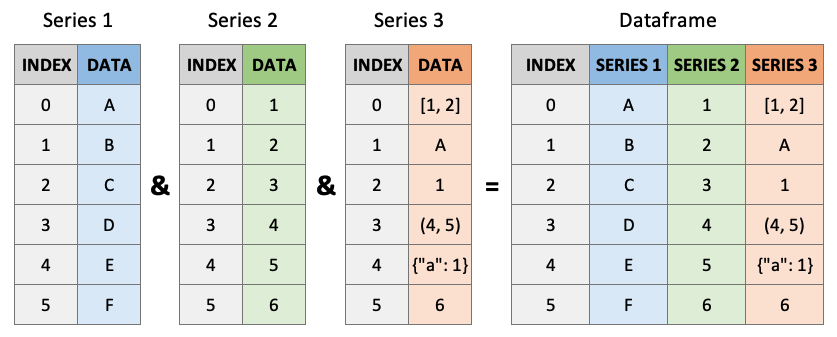

## **Creating a DataFrame from Python Objects**

We can create a Series from Python lists (also from NumPy arrays)

In [ ]:
np.random.seed(101)
mydata = np.random.randint(0,101,(4,3))
print(mydata)


[[95 11 81]
 [70 63 87]
 [75  9 77]
 [40  4 63]]


In [ ]:
df = pd.DataFrame(data=mydata)
df

,0,1,2
0,95,11,81
1,70,63,87
2,75,9,77
3,40,4,63


Note: both the D and the F are capitalized.

If you only provide the data, pandas automatically will label index 0, 1, 2, 3,... and it'll automatically label columns, 0, 1, 2 and so on.

In [ ]:
myindex = ['CA','NY','AZ','TX']

df = pd.DataFrame(data=mydata,index=myindex)
df

,0,1,2
CA,95,11,81
NY,70,63,87
AZ,75,9,77
TX,40,4,63


In [ ]:
mycolumns = ['Jan','Feb','Mar']
df = pd.DataFrame(data=mydata,index=myindex,columns=mycolumns)
df

,Jan,Feb,Mar
CA,95,11,81
NY,70,63,87
AZ,75,9,77
TX,40,4,63


To get general information about the dataframe:

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4 entries, CA to TX
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Jan     4 non-null      int64
 1   Feb     4 non-null      int64
 2   Mar     4 non-null      int64
dtypes: int64(3)
memory usage: 300.0+ bytes


<br><br>

## **Reading a .csv file for a DataFrame**

### **CSV**
Comma Separated Values files are text files that use commas as field delimeters.<br>

### **Understanding File Paths**

You have two options when reading a file with pandas:

1. If your .py file or .ipynb notebook is located in the **exact** same folder location as the .csv file you want to read, simply pass in the file name as a string, for example:
    
        df = pd.read_csv('some_file.csv')
        
2. Pass in the entire file path if you are located in a different directory. The file path must be 100% correct in order for this to work. For example for windows users:

        df = pd.read_csv("C:\\Users\\myself\\files\\some_file.csv")

`pwd` is a shell command. pwd stands for "print working directory". It's used to display the current directory you are operating in.

In [17]:
!pwd

/content


`ls` is another shell command. `ls` stands for "list segment". It's used to list the contents (files and directories) of the current working directory.

In [ ]:
!ls

sample_data  tips.csv


In [18]:
df = pd.read_csv('/content/tips.csv')
df

,total_bill,tip,sex,smoker,day,time,size,price_per_person,Payer Name,CC Number,Payment ID
0,16.99,1.01,Female,No,Sun,Dinner,2,8.49,Christy Cunningham,3560325168603410,Sun2959
1,10.34,1.66,Male,No,Sun,Dinner,3,3.45,Douglas Tucker,4478071379779230,Sun4608
2,21.01,3.50,Male,No,Sun,Dinner,3,7.00,Travis Walters,6011812112971322,Sun4458
3,23.68,3.31,Male,No,Sun,Dinner,2,11.84,Nathaniel Harris,4676137647685994,Sun5260
4,24.59,3.61,Female,No,Sun,Dinner,4,6.15,Tonya Carter,4832732618637221,Sun2251
...,...,...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,9.68,Michael Avila,5296068606052842,Sat2657
240,27.18,2.00,Female,Yes,Sat,Dinner,2,13.59,Monica Sanders,3506806155565404,Sat1766
241,22.67,2.00,Male,Yes,Sat,Dinner,2,11.34,Keith Wong,6011891618747196,Sat3880
242,17.82,1.75,Male,No,Sat,Dinner,2,8.91,Dennis Dixon,4375220550950,Sat17


----
About this DataSet (in case you are interested)

* Description
    * One waiter recorded information about each tip he received over a period of a few months working in one restaurant. He collected several variables:

* Format
    * A data frame with 244 rows and 7 variables

* Details
    * tip in dollars,
    * bill in dollars,
    * sex of the bill payer,
    * whether there were smokers in the party,
    * day of the week,
    * time of day,
    * size of the party.

In all he recorded 244 tips. The data was reported in a collection of case studies for business statistics (Bryant & Smith 1995).

----

<br><br>

## **Obtaining Basic Information About DataFrame**

In [19]:
df.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size',
       'price_per_person', 'Payer Name', 'CC Number', 'Payment ID'],
      dtype='object')

In [20]:
df.index

RangeIndex(start=0, stop=244, step=1)

Note: `.columns` and `.index` are attributes so there is no parenthesis in front of them vs `.head()` and `info()`

In [21]:
df.head(3)

,total_bill,tip,sex,smoker,day,time,size,price_per_person,Payer Name,CC Number,Payment ID
0,16.99,1.01,Female,No,Sun,Dinner,2,8.49,Christy Cunningham,3560325168603410,Sun2959
1,10.34,1.66,Male,No,Sun,Dinner,3,3.45,Douglas Tucker,4478071379779230,Sun4608
2,21.01,3.50,Male,No,Sun,Dinner,3,7.00,Travis Walters,6011812112971322,Sun4458


In [22]:
df.tail()

,total_bill,tip,sex,smoker,day,time,size,price_per_person,Payer Name,CC Number,Payment ID
239,29.03,5.92,Male,No,Sat,Dinner,3,9.68,Michael Avila,5296068606052842,Sat2657
240,27.18,2.00,Female,Yes,Sat,Dinner,2,13.59,Monica Sanders,3506806155565404,Sat1766
241,22.67,2.00,Male,Yes,Sat,Dinner,2,11.34,Keith Wong,6011891618747196,Sat3880
242,17.82,1.75,Male,No,Sat,Dinner,2,8.91,Dennis Dixon,4375220550950,Sat17
243,18.78,3.00,Female,No,Thur,Dinner,2,9.39,Michelle Hardin,3511451626698139,Thur672


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   total_bill        244 non-null    float64
 1   tip               244 non-null    float64
 2   sex               244 non-null    object 
 3   smoker            244 non-null    object 
 4   day               244 non-null    object 
 5   time              244 non-null    object 
 6   size              244 non-null    int64  
 7   price_per_person  244 non-null    float64
 8   Payer Name        244 non-null    object 
 9   CC Number         244 non-null    int64  
 10  Payment ID        244 non-null    object 
dtypes: float64(3), int64(2), object(6)
memory usage: 21.1+ KB


In [24]:
len(df)

244

`df.describe()` generates descriptive statistics of the DataFrame's numerical columns.



In [25]:
df.describe()

,total_bill,tip,size,price_per_person,CC Number
count,244.000000,244.000000,244.000000,244.000000,2.440000e+02
mean,19.785943,2.998279,2.569672,7.888197,2.563496e+15
std,8.902412,1.383638,0.951100,2.914234,2.369340e+15
min,3.070000,1.000000,1.000000,2.880000,6.040679e+10
25%,13.347500,2.000000,2.000000,5.800000,3.040731e+13
50%,17.795000,2.900000,2.000000,7.255000,3.525318e+15
75%,24.127500,3.562500,3.000000,9.390000,4.553675e+15
max,50.810000,10.000000,6.000000,20.270000,6.596454e+15


It provides a summary of central tendency, dispersion, and shape of the distribution for each numeric column, excluding `NaN` values. Specifically, it shows:

-  count: The number of non-null values.
-  mean: The average value.
-  std: The standard deviation, which measures the amount of variation or dispersion of a set of values.
-  min: The minimum value.
-  25% (1st quartile): The value below which 25% of the data falls.
-  50% (median, 2nd quartile): The middle value when the data is ordered.
ex: out of the total bills, 50% of them are below 17.79,and 50% of them are above 17.79.
-  75% (3rd quartile): The value below which 75% of the data falls.
-  max: The maximum value.

It helps in quickly understanding the distribution and identifying potential outliers or issues in your numerical data.

Note: Sometimes these attributes, or a statistical operations don't make sense for some columns for example credit card number here!

In [26]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
total_bill,244.0,1.978594e+01,8.902412e+00,3.070000e+00,1.334750e+01,1.779500e+01,2.412750e+01,5.081000e+01
tip,244.0,2.998279e+00,1.383638e+00,1.000000e+00,2.000000e+00,2.900000e+00,3.562500e+00,1.000000e+01
size,244.0,2.569672e+00,9.510998e-01,1.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
price_per_person,244.0,7.888197e+00,2.914234e+00,2.880000e+00,5.800000e+00,7.255000e+00,9.390000e+00,2.027000e+01
CC Number,244.0,2.563496e+15,2.369340e+15,6.040679e+10,3.040731e+13,3.525318e+15,4.553675e+15,6.596454e+15


<br><br>

## **Selection and Indexing**

Let's learn how to retrieve information from a DataFrame.

### **Columns**

We will begin be learning how to extract information based on the columns

In [27]:
df.head()

,total_bill,tip,sex,smoker,day,time,size,price_per_person,Payer Name,CC Number,Payment ID
0,16.99,1.01,Female,No,Sun,Dinner,2,8.49,Christy Cunningham,3560325168603410,Sun2959
1,10.34,1.66,Male,No,Sun,Dinner,3,3.45,Douglas Tucker,4478071379779230,Sun4608
2,21.01,3.50,Male,No,Sun,Dinner,3,7.00,Travis Walters,6011812112971322,Sun4458
3,23.68,3.31,Male,No,Sun,Dinner,2,11.84,Nathaniel Harris,4676137647685994,Sun5260
4,24.59,3.61,Female,No,Sun,Dinner,4,6.15,Tonya Carter,4832732618637221,Sun2251


#### **Grab a Single Column**

In [28]:
df['total_bill']

,total_bill
0,16.99
1,10.34
2,21.01
3,23.68
4,24.59
...,...
239,29.03
240,27.18
241,22.67
242,17.82


In [ ]:
type(df['total_bill'])

pandas.core.series.Series

#### **Grab Multiple Columns**

In [ ]:
# Note how its a python list of column names! Thus the double brackets.
df[['total_bill','tip']]

,total_bill,tip
0,16.99,1.01
1,10.34,1.66
2,21.01,3.50
3,23.68,3.31
4,24.59,3.61
...,...,...
239,29.03,5.92
240,27.18,2.00
241,22.67,2.00
242,17.82,1.75


#### **Create New Columns**

In [29]:
100 * df['tip'] / df['total_bill']

,0
0,5.944673
1,16.054159
2,16.658734
3,13.978041
4,14.680765
...,...
239,20.392697
240,7.358352
241,8.822232
242,9.820426


In [30]:
df['tip_percentage'] = 100 * df['tip'] / df['total_bill']

In [ ]:
df.head()

,total_bill,tip,sex,smoker,day,time,size,price_per_person,Payer Name,CC Number,Payment ID,tip_percentage
0,16.99,1.01,Female,No,Sun,Dinner,2,8.49,Christy Cunningham,3560325168603410,Sun2959,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,3.45,Douglas Tucker,4478071379779230,Sun4608,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,7.00,Travis Walters,6011812112971322,Sun4458,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,11.84,Nathaniel Harris,4676137647685994,Sun5260,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,6.15,Tonya Carter,4832732618637221,Sun2251,14.680765


In [31]:
df['price_per_person'] = df['total_bill'] / df['size']

In [32]:
df.head()

,total_bill,tip,sex,smoker,day,time,size,price_per_person,Payer Name,CC Number,Payment ID,tip_percentage
0,16.99,1.01,Female,No,Sun,Dinner,2,8.495000,Christy Cunningham,3560325168603410,Sun2959,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,3.446667,Douglas Tucker,4478071379779230,Sun4608,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,7.003333,Travis Walters,6011812112971322,Sun4458,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,11.840000,Nathaniel Harris,4676137647685994,Sun5260,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,6.147500,Tonya Carter,4832732618637221,Sun2251,14.680765


#### **Adjust Existing Columns**

In [ ]:
# Because pandas is based on numpy, we get awesome capabilities with numpy's universal functions!
df['price_per_person'] = np.round(df['price_per_person'],2)

In [ ]:
df.head()

,total_bill,tip,sex,smoker,day,time,size,price_per_person,Payer Name,CC Number,Payment ID,tip_percentage
0,16.99,1.01,Female,No,Sun,Dinner,2,8.49,Christy Cunningham,3560325168603410,Sun2959,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,3.45,Douglas Tucker,4478071379779230,Sun4608,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,7.00,Travis Walters,6011812112971322,Sun4458,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,11.84,Nathaniel Harris,4676137647685994,Sun5260,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,6.15,Tonya Carter,4832732618637221,Sun2251,14.680765


#### **Remove Columns**

If not specify the axis will get error, because the default axis is zero and it cannot find along row

In [ ]:
df.drop("tip_percentage",axis=1)

,total_bill,tip,sex,smoker,day,time,size,price_per_person,Payer Name,CC Number,Payment ID
0,16.99,1.01,Female,No,Sun,Dinner,2,8.49,Christy Cunningham,3560325168603410,Sun2959
1,10.34,1.66,Male,No,Sun,Dinner,3,3.45,Douglas Tucker,4478071379779230,Sun4608
2,21.01,3.50,Male,No,Sun,Dinner,3,7.00,Travis Walters,6011812112971322,Sun4458
3,23.68,3.31,Male,No,Sun,Dinner,2,11.84,Nathaniel Harris,4676137647685994,Sun5260
4,24.59,3.61,Female,No,Sun,Dinner,4,6.15,Tonya Carter,4832732618637221,Sun2251
...,...,...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,9.68,Michael Avila,5296068606052842,Sat2657
240,27.18,2.00,Female,Yes,Sat,Dinner,2,13.59,Monica Sanders,3506806155565404,Sat1766
241,22.67,2.00,Male,Yes,Sat,Dinner,2,11.34,Keith Wong,6011891618747196,Sat3880
242,17.82,1.75,Male,No,Sat,Dinner,2,8.91,Dennis Dixon,4375220550950,Sat17


In [ ]:
df

,total_bill,tip,sex,smoker,day,time,size,price_per_person,Payer Name,CC Number,Payment ID,tip_percentage
0,16.99,1.01,Female,No,Sun,Dinner,2,8.49,Christy Cunningham,3560325168603410,Sun2959,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,3.45,Douglas Tucker,4478071379779230,Sun4608,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,7.00,Travis Walters,6011812112971322,Sun4458,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,11.84,Nathaniel Harris,4676137647685994,Sun5260,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,6.15,Tonya Carter,4832732618637221,Sun2251,14.680765
...,...,...,...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,9.68,Michael Avila,5296068606052842,Sat2657,20.392697
240,27.18,2.00,Female,Yes,Sat,Dinner,2,13.59,Monica Sanders,3506806155565404,Sat1766,7.358352
241,22.67,2.00,Male,Yes,Sat,Dinner,2,11.34,Keith Wong,6011891618747196,Sat3880,8.822232
242,17.82,1.75,Male,No,Sat,Dinner,2,8.91,Dennis Dixon,4375220550950,Sat17,9.820426


**Notice:** The change will not persist unless `inplace=True` is used or the result is reassigned to `df` (or another variable).

In [ ]:
# df.drop("tip_percentage",axis=1, inplace=True)

In [ ]:
df = df.drop("tip_percentage",axis=1)

In [ ]:
df.head()

,total_bill,tip,sex,smoker,day,time,size,price_per_person,Payer Name,CC Number,Payment ID
0,16.99,1.01,Female,No,Sun,Dinner,2,8.49,Christy Cunningham,3560325168603410,Sun2959
1,10.34,1.66,Male,No,Sun,Dinner,3,3.45,Douglas Tucker,4478071379779230,Sun4608
2,21.01,3.50,Male,No,Sun,Dinner,3,7.00,Travis Walters,6011812112971322,Sun4458
3,23.68,3.31,Male,No,Sun,Dinner,2,11.84,Nathaniel Harris,4676137647685994,Sun5260
4,24.59,3.61,Female,No,Sun,Dinner,4,6.15,Tonya Carter,4832732618637221,Sun2251


<br><br>

### **Index Basics**


In [ ]:
df.index

RangeIndex(start=0, stop=244, step=1)

Index must be unique value for each row, right now it is unique but if we want to set it to a column, in this dataset `'Payment ID'` can be a good candidate:

In [ ]:
df.set_index('Payment ID')

,total_bill,tip,sex,smoker,day,time,size,price_per_person,Payer Name,CC Number
Payment ID,,,,,,,,,,
Sun2959,16.99,1.01,Female,No,Sun,Dinner,2,8.49,Christy Cunningham,3560325168603410
Sun4608,10.34,1.66,Male,No,Sun,Dinner,3,3.45,Douglas Tucker,4478071379779230
Sun4458,21.01,3.50,Male,No,Sun,Dinner,3,7.00,Travis Walters,6011812112971322
Sun5260,23.68,3.31,Male,No,Sun,Dinner,2,11.84,Nathaniel Harris,4676137647685994
Sun2251,24.59,3.61,Female,No,Sun,Dinner,4,6.15,Tonya Carter,4832732618637221
...,...,...,...,...,...,...,...,...,...,...
Sat2657,29.03,5.92,Male,No,Sat,Dinner,3,9.68,Michael Avila,5296068606052842
Sat1766,27.18,2.00,Female,Yes,Sat,Dinner,2,13.59,Monica Sanders,3506806155565404
Sat3880,22.67,2.00,Male,Yes,Sat,Dinner,2,11.34,Keith Wong,6011891618747196


Now `Payment ID`, is not a column anymore, it is name of the index and the values in bold are the index values, so we can grab rows based on the `Payment ID`

Again this is not permanent untill we assign it to a variable


In [35]:
df = df.set_index('Payment ID')
df

,total_bill,tip,sex,smoker,day,time,size,price_per_person,Payer Name,CC Number,tip_percentage
Payment ID,,,,,,,,,,,
Sun2959,16.99,1.01,Female,No,Sun,Dinner,2,8.495000,Christy Cunningham,3560325168603410,5.944673
Sun4608,10.34,1.66,Male,No,Sun,Dinner,3,3.446667,Douglas Tucker,4478071379779230,16.054159
Sun4458,21.01,3.50,Male,No,Sun,Dinner,3,7.003333,Travis Walters,6011812112971322,16.658734
Sun5260,23.68,3.31,Male,No,Sun,Dinner,2,11.840000,Nathaniel Harris,4676137647685994,13.978041
Sun2251,24.59,3.61,Female,No,Sun,Dinner,4,6.147500,Tonya Carter,4832732618637221,14.680765
...,...,...,...,...,...,...,...,...,...,...,...
Sat2657,29.03,5.92,Male,No,Sat,Dinner,3,9.676667,Michael Avila,5296068606052842,20.392697
Sat1766,27.18,2.00,Female,Yes,Sat,Dinner,2,13.590000,Monica Sanders,3506806155565404,7.358352
Sat3880,22.67,2.00,Male,Yes,Sat,Dinner,2,11.335000,Keith Wong,6011891618747196,8.822232


In [ ]:
df = df.reset_index()
df

,Payment ID,total_bill,tip,sex,smoker,day,time,size,price_per_person,Payer Name,CC Number
0,Sun2959,16.99,1.01,Female,No,Sun,Dinner,2,8.49,Christy Cunningham,3560325168603410
1,Sun4608,10.34,1.66,Male,No,Sun,Dinner,3,3.45,Douglas Tucker,4478071379779230
2,Sun4458,21.01,3.50,Male,No,Sun,Dinner,3,7.00,Travis Walters,6011812112971322
3,Sun5260,23.68,3.31,Male,No,Sun,Dinner,2,11.84,Nathaniel Harris,4676137647685994
4,Sun2251,24.59,3.61,Female,No,Sun,Dinner,4,6.15,Tonya Carter,4832732618637221
...,...,...,...,...,...,...,...,...,...,...,...
239,Sat2657,29.03,5.92,Male,No,Sat,Dinner,3,9.68,Michael Avila,5296068606052842
240,Sat1766,27.18,2.00,Female,Yes,Sat,Dinner,2,13.59,Monica Sanders,3506806155565404
241,Sat3880,22.67,2.00,Male,Yes,Sat,Dinner,2,11.34,Keith Wong,6011891618747196
242,Sat17,17.82,1.75,Male,No,Sat,Dinner,2,8.91,Dennis Dixon,4375220550950


<br>

In [ ]:
df = df.set_index('sex')

In [ ]:
df.head()

,Payment ID,total_bill,tip,smoker,day,time,size,price_per_person,Payer Name,CC Number
sex,,,,,,,,,,
Female,Sun2959,16.99,1.01,No,Sun,Dinner,2,8.49,Christy Cunningham,3560325168603410
Male,Sun4608,10.34,1.66,No,Sun,Dinner,3,3.45,Douglas Tucker,4478071379779230
Male,Sun4458,21.01,3.50,No,Sun,Dinner,3,7.00,Travis Walters,6011812112971322
Male,Sun5260,23.68,3.31,No,Sun,Dinner,2,11.84,Nathaniel Harris,4676137647685994
Female,Sun2251,24.59,3.61,No,Sun,Dinner,4,6.15,Tonya Carter,4832732618637221


In [ ]:
df = df.reset_index()

In [ ]:
df.head()

,sex,Payment ID,total_bill,tip,smoker,day,time,size,price_per_person,Payer Name,CC Number
0,Female,Sun2959,16.99,1.01,No,Sun,Dinner,2,8.49,Christy Cunningham,3560325168603410
1,Male,Sun4608,10.34,1.66,No,Sun,Dinner,3,3.45,Douglas Tucker,4478071379779230
2,Male,Sun4458,21.01,3.50,No,Sun,Dinner,3,7.00,Travis Walters,6011812112971322
3,Male,Sun5260,23.68,3.31,No,Sun,Dinner,2,11.84,Nathaniel Harris,4676137647685994
4,Female,Sun2251,24.59,3.61,No,Sun,Dinner,4,6.15,Tonya Carter,4832732618637221


### **ROWS**

Let's now explore these same concepts but with Rows.

In [ ]:
df = df.set_index('Payment ID')

In [ ]:
df.head()

,sex,total_bill,tip,smoker,day,time,size,price_per_person,Payer Name,CC Number
Payment ID,,,,,,,,,,
Sun2959,Female,16.99,1.01,No,Sun,Dinner,2,8.49,Christy Cunningham,3560325168603410
Sun4608,Male,10.34,1.66,No,Sun,Dinner,3,3.45,Douglas Tucker,4478071379779230
Sun4458,Male,21.01,3.50,No,Sun,Dinner,3,7.00,Travis Walters,6011812112971322
Sun5260,Male,23.68,3.31,No,Sun,Dinner,2,11.84,Nathaniel Harris,4676137647685994
Sun2251,Female,24.59,3.61,No,Sun,Dinner,4,6.15,Tonya Carter,4832732618637221


#### **Grab a Single Row**

In [36]:
# Integer Based
df.iloc[0]

,Sun2959
total_bill,16.99
tip,1.01
sex,Female
smoker,No
day,Sun
time,Dinner
size,2
price_per_person,8.495
Payer Name,Christy Cunningham
CC Number,3560325168603410


In [ ]:
# Name Based
df.loc['Sun2959']

,Sun2959
sex,Female
total_bill,16.99
tip,1.01
smoker,No
day,Sun
time,Dinner
size,2
price_per_person,8.49
Payer Name,Christy Cunningham
CC Number,3560325168603410


#### **Grab Multiple Rows**

In [ ]:
df.iloc[0:4]

,sex,total_bill,tip,smoker,day,time,size,price_per_person,Payer Name,CC Number
Payment ID,,,,,,,,,,
Sun2959,Female,16.99,1.01,No,Sun,Dinner,2,8.49,Christy Cunningham,3560325168603410
Sun4608,Male,10.34,1.66,No,Sun,Dinner,3,3.45,Douglas Tucker,4478071379779230
Sun4458,Male,21.01,3.50,No,Sun,Dinner,3,7.00,Travis Walters,6011812112971322
Sun5260,Male,23.68,3.31,No,Sun,Dinner,2,11.84,Nathaniel Harris,4676137647685994


In [ ]:
df.loc[['Sun2959','Sun5260']]

,sex,total_bill,tip,smoker,day,time,size,price_per_person,Payer Name,CC Number
Payment ID,,,,,,,,,,
Sun2959,Female,16.99,1.01,No,Sun,Dinner,2,8.49,Christy Cunningham,3560325168603410
Sun5260,Male,23.68,3.31,No,Sun,Dinner,2,11.84,Nathaniel Harris,4676137647685994


#### **Remove Row**

Typically are datasets will be large enough that we won't remove rows like this since we won't know thier row location for some specific condition, instead, we drop rows based on conditions such as missing data or column values. The next lecture will cover this in a lot more detail.

In [ ]:
df.head()

,sex,total_bill,tip,smoker,day,time,size,price_per_person,Payer Name,CC Number
Payment ID,,,,,,,,,,
Sun2959,Female,16.99,1.01,No,Sun,Dinner,2,8.49,Christy Cunningham,3560325168603410
Sun4608,Male,10.34,1.66,No,Sun,Dinner,3,3.45,Douglas Tucker,4478071379779230
Sun4458,Male,21.01,3.50,No,Sun,Dinner,3,7.00,Travis Walters,6011812112971322
Sun5260,Male,23.68,3.31,No,Sun,Dinner,2,11.84,Nathaniel Harris,4676137647685994
Sun2251,Female,24.59,3.61,No,Sun,Dinner,4,6.15,Tonya Carter,4832732618637221


In [ ]:
df.drop('Sun2959',axis=0).head()

,sex,total_bill,tip,smoker,day,time,size,price_per_person,Payer Name,CC Number
Payment ID,,,,,,,,,,
Sun4608,Male,10.34,1.66,No,Sun,Dinner,3,3.45,Douglas Tucker,4478071379779230
Sun4458,Male,21.01,3.50,No,Sun,Dinner,3,7.00,Travis Walters,6011812112971322
Sun5260,Male,23.68,3.31,No,Sun,Dinner,2,11.84,Nathaniel Harris,4676137647685994
Sun2251,Female,24.59,3.61,No,Sun,Dinner,4,6.15,Tonya Carter,4832732618637221
Sun9679,Male,25.29,4.71,No,Sun,Dinner,4,6.32,Erik Smith,213140353657882


In [ ]:
df.head()

,sex,total_bill,tip,smoker,day,time,size,price_per_person,Payer Name,CC Number
Payment ID,,,,,,,,,,
Sun2959,Female,16.99,1.01,No,Sun,Dinner,2,8.49,Christy Cunningham,3560325168603410
Sun4608,Male,10.34,1.66,No,Sun,Dinner,3,3.45,Douglas Tucker,4478071379779230
Sun4458,Male,21.01,3.50,No,Sun,Dinner,3,7.00,Travis Walters,6011812112971322
Sun5260,Male,23.68,3.31,No,Sun,Dinner,2,11.84,Nathaniel Harris,4676137647685994
Sun2251,Female,24.59,3.61,No,Sun,Dinner,4,6.15,Tonya Carter,4832732618637221


Again this is not permanent untill we assign it to a variable!

In [ ]:
df = df.drop('Sun2959',axis=0)
df.head()

,sex,total_bill,tip,smoker,day,time,size,price_per_person,Payer Name,CC Number
Payment ID,,,,,,,,,,
Sun4608,Male,10.34,1.66,No,Sun,Dinner,3,3.45,Douglas Tucker,4478071379779230
Sun4458,Male,21.01,3.50,No,Sun,Dinner,3,7.00,Travis Walters,6011812112971322
Sun5260,Male,23.68,3.31,No,Sun,Dinner,2,11.84,Nathaniel Harris,4676137647685994
Sun2251,Female,24.59,3.61,No,Sun,Dinner,4,6.15,Tonya Carter,4832732618637221
Sun9679,Male,25.29,4.71,No,Sun,Dinner,4,6.32,Erik Smith,213140353657882


In [ ]:
# Error if you have a named index!
# df.drop(0,axis=0).head()

#### **Insert a New Row**

Pretty rare to add a single row like this. Usually you use pd.concat() to add many rows at once. You could use the .append() method with a list of pd.Series() objects, but you won't see us do this with realistic real-world data.

Note: New row, it needs to match up with the dimensions of your current data frame.

In [37]:
one_row = df.iloc[0]

In [38]:
one_row

,Sun2959
total_bill,16.99
tip,1.01
sex,Female
smoker,No
day,Sun
time,Dinner
size,2
price_per_person,8.495
Payer Name,Christy Cunningham
CC Number,3560325168603410


In [ ]:
type(one_row)

pandas.core.series.Series

In [39]:
df.tail()

,total_bill,tip,sex,smoker,day,time,size,price_per_person,Payer Name,CC Number,tip_percentage
Payment ID,,,,,,,,,,,
Sat2657,29.03,5.92,Male,No,Sat,Dinner,3,9.676667,Michael Avila,5296068606052842,20.392697
Sat1766,27.18,2.00,Female,Yes,Sat,Dinner,2,13.590000,Monica Sanders,3506806155565404,7.358352
Sat3880,22.67,2.00,Male,Yes,Sat,Dinner,2,11.335000,Keith Wong,6011891618747196,8.822232
Sat17,17.82,1.75,Male,No,Sat,Dinner,2,8.910000,Dennis Dixon,4375220550950,9.820426
Thur672,18.78,3.00,Female,No,Thur,Dinner,2,9.390000,Michelle Hardin,3511451626698139,15.974441


In [43]:
df = pd.concat([df, one_row.to_frame().T]).tail()

In [44]:
df.tail()

,total_bill,tip,sex,smoker,day,time,size,price_per_person,Payer Name,CC Number,tip_percentage
Sat1766,27.18,2.0,Female,Yes,Sat,Dinner,2,13.59,Monica Sanders,3506806155565404,7.358352
Sat3880,22.67,2.0,Male,Yes,Sat,Dinner,2,11.335,Keith Wong,6011891618747196,8.822232
Sat17,17.82,1.75,Male,No,Sat,Dinner,2,8.91,Dennis Dixon,4375220550950,9.820426
Thur672,18.78,3.0,Female,No,Thur,Dinner,2,9.39,Michelle Hardin,3511451626698139,15.974441
Sun2959,16.99,1.01,Female,No,Sun,Dinner,2,8.495,Christy Cunningham,3560325168603410,5.944673


<br><br>

### **Conditional Filtering**

Allows us to select based on logical conditioning.

In [ ]:
bool_series = df['total_bill'] > 30

In [ ]:
bool_series

,total_bill
Payment ID,
Sun2959,False
Sun4608,False
Sun4458,False
Sun5260,False
Sun2251,False
...,...
Sat2657,False
Sat1766,False
Sat3880,False


In [ ]:
df[bool_series]

,total_bill,tip,sex,smoker,day,time,size,price_per_person,Payer Name,CC Number
Payment ID,,,,,,,,,,
Sun6686,35.26,5.00,Female,No,Sun,Dinner,4,8.82,Diane Macias,4577817359320969
Sat239,39.42,7.58,Male,No,Sat,Dinner,4,9.86,Lance Peterson,3542584061609808
Sat6373,31.27,5.00,Male,No,Sat,Dinner,3,10.42,Mr. Brandon Berry,6011525851069856
Sun2274,30.40,5.60,Male,No,Sun,Dinner,4,7.60,Todd Cooper,503846761263
Sun9677,32.40,6.00,Male,No,Sun,Dinner,4,8.10,James Barnes,3552002592874186
Sun6165,34.81,5.20,Female,No,Sun,Dinner,4,8.70,Emily Daniel,4291280793094374
Sat8903,38.01,3.00,Male,Yes,Sat,Dinner,4,9.50,James Christensen DDS,349793629453226
Sat8139,48.27,6.73,Male,No,Sat,Dinner,4,12.07,Brian Ortiz,6596453823950595
Thur8801,32.68,5.00,Male,Yes,Thur,Lunch,2,16.34,Daniel Murphy,5356177501009133


In [ ]:
df[df['total_bill']>30]

,total_bill,tip,sex,smoker,day,time,size,price_per_person,Payer Name,CC Number
Payment ID,,,,,,,,,,
Sun6686,35.26,5.00,Female,No,Sun,Dinner,4,8.82,Diane Macias,4577817359320969
Sat239,39.42,7.58,Male,No,Sat,Dinner,4,9.86,Lance Peterson,3542584061609808
Sat6373,31.27,5.00,Male,No,Sat,Dinner,3,10.42,Mr. Brandon Berry,6011525851069856
Sun2274,30.40,5.60,Male,No,Sun,Dinner,4,7.60,Todd Cooper,503846761263
Sun9677,32.40,6.00,Male,No,Sun,Dinner,4,8.10,James Barnes,3552002592874186
Sun6165,34.81,5.20,Female,No,Sun,Dinner,4,8.70,Emily Daniel,4291280793094374
Sat8903,38.01,3.00,Male,Yes,Sat,Dinner,4,9.50,James Christensen DDS,349793629453226
Sat8139,48.27,6.73,Male,No,Sat,Dinner,4,12.07,Brian Ortiz,6596453823950595
Thur8801,32.68,5.00,Male,Yes,Thur,Lunch,2,16.34,Daniel Murphy,5356177501009133


In [ ]:
df[df['sex'] == 'Male']

,total_bill,tip,sex,smoker,day,time,size,price_per_person,Payer Name,CC Number
Payment ID,,,,,,,,,,
Sun4608,10.34,1.66,Male,No,Sun,Dinner,3,3.45,Douglas Tucker,4478071379779230
Sun4458,21.01,3.50,Male,No,Sun,Dinner,3,7.00,Travis Walters,6011812112971322
Sun5260,23.68,3.31,Male,No,Sun,Dinner,2,11.84,Nathaniel Harris,4676137647685994
Sun9679,25.29,4.71,Male,No,Sun,Dinner,4,6.32,Erik Smith,213140353657882
Sun5985,8.77,2.00,Male,No,Sun,Dinner,2,4.38,Kristopher Johnson,2223727524230344
...,...,...,...,...,...,...,...,...,...,...
Sat5032,12.60,1.00,Male,Yes,Sat,Dinner,2,6.30,Matthew Myers,3543676378973965
Sat2929,32.83,1.17,Male,Yes,Sat,Dinner,2,16.42,Thomas Brown,4284722681265508
Sat2657,29.03,5.92,Male,No,Sat,Dinner,3,9.68,Michael Avila,5296068606052842


## **Multiple Conditions**

Recall the steps:

* Get the conditions
* Wrap each condition in parenthesis
* Use the | or & operator, depending if you want an
    * OR | (either condition is True)
    * AND & (both conditions must be True)
* You can also use the ~ operator as a NOT operation

In [ ]:
df[(df['total_bill'] > 30) & (df['sex']=='Male')]

,total_bill,tip,sex,smoker,day,time,size,price_per_person,Payer Name,CC Number
Payment ID,,,,,,,,,,
Sat239,39.42,7.58,Male,No,Sat,Dinner,4,9.86,Lance Peterson,3542584061609808
Sat6373,31.27,5.00,Male,No,Sat,Dinner,3,10.42,Mr. Brandon Berry,6011525851069856
Sun2274,30.40,5.60,Male,No,Sun,Dinner,4,7.60,Todd Cooper,503846761263
Sun9677,32.40,6.00,Male,No,Sun,Dinner,4,8.10,James Barnes,3552002592874186
Sat8903,38.01,3.00,Male,Yes,Sat,Dinner,4,9.50,James Christensen DDS,349793629453226
Sat8139,48.27,6.73,Male,No,Sat,Dinner,4,12.07,Brian Ortiz,6596453823950595
Thur8801,32.68,5.00,Male,Yes,Thur,Lunch,2,16.34,Daniel Murphy,5356177501009133
Fri9628,40.17,4.73,Male,Yes,Fri,Dinner,4,10.04,Aaron Bentley,180026611638690
Sun591,38.07,4.00,Male,No,Sun,Dinner,3,12.69,Jeff Lopez,3572865915176463


In [ ]:
df[(df['total_bill'] > 30) & ~(df['sex']=='Male')]

,total_bill,tip,sex,smoker,day,time,size,price_per_person,Payer Name,CC Number
Payment ID,,,,,,,,,,
Sun6686,35.26,5.00,Female,No,Sun,Dinner,4,8.82,Diane Macias,4577817359320969
Sun6165,34.81,5.20,Female,No,Sun,Dinner,4,8.70,Emily Daniel,4291280793094374
Thur7972,34.83,5.17,Female,No,Thur,Lunch,4,8.71,Shawna Cook,6011787464177340
Sat6240,44.30,2.50,Female,Yes,Sat,Dinner,3,14.77,Heather Cohen,379771118886604
Thur9313,43.11,5.00,Female,Yes,Thur,Lunch,4,10.78,Brooke Soto,5544902205760175
Sat8863,30.14,3.09,Female,Yes,Sat,Dinner,4,7.54,Shelby House,502097403252
Sat9777,35.83,4.67,Female,No,Sat,Dinner,3,11.94,Kimberly Crane,676184013727


In [ ]:
df[(df['total_bill'] > 30) & (df['sex']!='Male')]

,total_bill,tip,sex,smoker,day,time,size,price_per_person,Payer Name,CC Number
Payment ID,,,,,,,,,,
Sun6686,35.26,5.00,Female,No,Sun,Dinner,4,8.82,Diane Macias,4577817359320969
Sun6165,34.81,5.20,Female,No,Sun,Dinner,4,8.70,Emily Daniel,4291280793094374
Thur7972,34.83,5.17,Female,No,Thur,Lunch,4,8.71,Shawna Cook,6011787464177340
Sat6240,44.30,2.50,Female,Yes,Sat,Dinner,3,14.77,Heather Cohen,379771118886604
Thur9313,43.11,5.00,Female,Yes,Thur,Lunch,4,10.78,Brooke Soto,5544902205760175
Sat8863,30.14,3.09,Female,Yes,Sat,Dinner,4,7.54,Shelby House,502097403252
Sat9777,35.83,4.67,Female,No,Sat,Dinner,3,11.94,Kimberly Crane,676184013727


In [ ]:
df[(df['day'] =='Sun') | (df['day']=='Sat')]

,total_bill,tip,sex,smoker,day,time,size,price_per_person,Payer Name,CC Number
Payment ID,,,,,,,,,,
Sun2959,16.99,1.01,Female,No,Sun,Dinner,2,8.49,Christy Cunningham,3560325168603410
Sun4608,10.34,1.66,Male,No,Sun,Dinner,3,3.45,Douglas Tucker,4478071379779230
Sun4458,21.01,3.50,Male,No,Sun,Dinner,3,7.00,Travis Walters,6011812112971322
Sun5260,23.68,3.31,Male,No,Sun,Dinner,2,11.84,Nathaniel Harris,4676137647685994
Sun2251,24.59,3.61,Female,No,Sun,Dinner,4,6.15,Tonya Carter,4832732618637221
...,...,...,...,...,...,...,...,...,...,...
Sat9777,35.83,4.67,Female,No,Sat,Dinner,3,11.94,Kimberly Crane,676184013727
Sat2657,29.03,5.92,Male,No,Sat,Dinner,3,9.68,Michael Avila,5296068606052842
Sat1766,27.18,2.00,Female,Yes,Sat,Dinner,2,13.59,Monica Sanders,3506806155565404


### **Conditional Operator isin()**

We can use .isin() operator to filter by a list of options.

In [ ]:
options = ['Sat','Sun']
df['day'].isin(options)

,day
Payment ID,
Sun2959,True
Sun4608,True
Sun4458,True
Sun5260,True
Sun2251,True
...,...
Sat2657,True
Sat1766,True
Sat3880,True


In [ ]:
df[df['day'].isin(['Sat','Sun'])]

,total_bill,tip,sex,smoker,day,time,size,price_per_person,Payer Name,CC Number
Payment ID,,,,,,,,,,
Sun2959,16.99,1.01,Female,No,Sun,Dinner,2,8.49,Christy Cunningham,3560325168603410
Sun4608,10.34,1.66,Male,No,Sun,Dinner,3,3.45,Douglas Tucker,4478071379779230
Sun4458,21.01,3.50,Male,No,Sun,Dinner,3,7.00,Travis Walters,6011812112971322
Sun5260,23.68,3.31,Male,No,Sun,Dinner,2,11.84,Nathaniel Harris,4676137647685994
Sun2251,24.59,3.61,Female,No,Sun,Dinner,4,6.15,Tonya Carter,4832732618637221
...,...,...,...,...,...,...,...,...,...,...
Sat9777,35.83,4.67,Female,No,Sat,Dinner,3,11.94,Kimberly Crane,676184013727
Sat2657,29.03,5.92,Male,No,Sat,Dinner,3,9.68,Michael Avila,5296068606052842
Sat1766,27.18,2.00,Female,Yes,Sat,Dinner,2,13.59,Monica Sanders,3506806155565404


<br> <br>

## **Practice Questions**

1.  How would you select the rows for `Payment ID` 'Sun4458' and 'Sat17'?
2.  How would you select the first 5 rows and only the 'total_bill' and 'tip' columns?
3.  Select all entries where the `total_bill` is less than 15 AND the `smoker` is 'No'.
4.  Select all entries where the `day` is 'Thur' OR the `time` is 'Lunch'.
5.  **Using `isin()`:** Filter the DataFrame to show only entries where the `sex` is either 'Female' or 'Male' (this should return the full DataFrame, but demonstrates the use of `isin()`).

6.  Select all records where the `size` of the party is 2 AND the `total_bill` is greater than 25.

7. Select all entries where `total_bill` is greater than 30, the customer is a non-smoker, and the `day` is either 'Sat' or 'Sun'.

8. Find all female diners who tipped between 2.00 and 4.00 (inclusive) and dined on a 'Thur'.

9. Select entries where the `size` of the party is 4 or more, but the `price_per_person` is less than 7.00.



<br> <br>

**Reference:** Pierian Data — Python & Data Science Training  
https://pieriantraining.com
